In [1]:
# @title Configuração de Ambiente
!pip -q install scikit-learn deap pandas seaborn

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print('✅ Ambiente configurado: scikit-learn, DEAP, pandas e seaborn prontos.')
# Saída Esperada: ✅ Ambiente configurado: scikit-learn, DEAP, pandas e seaborn prontos.


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
✅ Ambiente configurado: scikit-learn, DEAP, pandas e seaborn prontos.
✅ Ambiente configurado: scikit-learn, DEAP, pandas e seaborn prontos.


# Workshop Prático: Fairness Testing com SBSE

Neste laboratório você irá gerar perfis sintéticos para um modelo de crédito enviesado, comparar busca aleatória com algoritmos genéticos (DEAP) e calcular métricas de justiça para expor vieses.

In [2]:
# @title Dataset sintético enviesado e modelo alvo
import json
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def logistic(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

rng = np.random.default_rng(42)
n_samples = 5000
age = rng.integers(21, 66, size=n_samples)
salary = rng.normal(60000, 18000, size=n_samples).clip(20000, 160000)
credit_score = rng.integers(300, 851, size=n_samples)
years_experience = np.clip(age - rng.integers(18, 36, size=n_samples), 0, 40)
gender = rng.choice(['M', 'F'], size=n_samples, p=[0.5, 0.5])
ethnicity = rng.choice(['BRANCA', 'PARDA', 'PRETA'], size=n_samples, p=[0.5, 0.3, 0.2])

base_score = (
    0.25 * (age / 65) +
    0.35 * (salary / 160000) +
    0.25 * (credit_score / 850) +
    0.15 * (years_experience / 40)
)
true_prob = logistic(base_score * 6 - 3)
bias = np.zeros(n_samples)
bias += np.where(gender == 'F', -0.15, 0.0)
bias += np.where(ethnicity == 'PRETA', -0.10, 0.0)
biased_prob = np.clip(true_prob + bias, 0.01, 0.99)

true_label = (true_prob >= 0.5).astype(int)
biased_label = (biased_prob >= 0.5).astype(int)

df = pd.DataFrame({
    'age': age,
    'salary': salary.round(2),
    'credit_score': credit_score,
    'years_experience': years_experience,
    'gender': gender,
    'ethnicity': ethnicity,
    'true_label': true_label,
    'label': biased_label,
    'true_prob': true_prob,
    'biased_prob': biased_prob
})

features = ['age', 'salary', 'credit_score', 'years_experience', 'gender', 'ethnicity']
target = 'label'

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'salary', 'credit_score', 'years_experience']),
        ('cat', OneHotEncoder(drop='first'), ['gender', 'ethnicity'])
    ]
)
model = Pipeline(
    steps=[
        ('prep', preprocess),
        ('clf', LogisticRegression(max_iter=1000))
    ]
)
model.fit(df[features], df[target])

gender_values = ['M', 'F']
ethnicity_values = ['BRANCA', 'PARDA', 'PRETA']
numeric_bounds = {
    'age': (21, 65),
    'salary': (20000.0, 160000.0),
    'credit_score': (300, 850),
    'years_experience': (0, 40)
}

def base_probability(profile: Dict[str, float]) -> float:
    base = (
        0.25 * (profile['age'] / 65) +
        0.35 * (profile['salary'] / 160000) +
        0.25 * (profile['credit_score'] / 850) +
        0.15 * (profile['years_experience'] / 40)
    )
    return float(logistic(base * 6 - 3))

gender_bias = df.groupby('gender')['label'].mean().round(3)
eth_bias = df.groupby('ethnicity')['label'].mean().round(3)

print(f'📦 Dataset gerado: {df.shape[0]} linhas, {len(features)} atributos.')
print('⚖️ Taxa de aprovação por gênero (rótulo enviesado):')
print(gender_bias.to_string())
print('\n⚖️ Taxa de aprovação por etnia (rótulo enviesado):')
print(eth_bias.to_string())
# Saída Esperada:


# 📦 Dataset gerado: 5000 linhas, 6 atributos.
# ⚖️ Taxa de aprovação por gênero (rótulo enviesado): F < M
# ⚖️ Taxa de aprovação por etnia (rótulo enviesado): PRETA < PARDA < BRANCA

📦 Dataset gerado: 5000 linhas, 6 atributos.
⚖️ Taxa de aprovação por gênero (rótulo enviesado):
gender
F    0.242
M    0.537

⚖️ Taxa de aprovação por etnia (rótulo enviesado):
ethnicity
BRANCA    0.432
PARDA     0.436
PRETA     0.214


In [3]:
# @title Funções utilitárias de fairness
from dataclasses import dataclass

def vector_to_profile(vector: List[float]) -> Dict[str, float]:
    vector = list(vector)
    profile = {
        'age': int(np.clip(round(vector[0]), *numeric_bounds['age'])),
        'salary': float(np.clip(vector[1], *numeric_bounds['salary'])),
        'credit_score': int(np.clip(round(vector[2]), *numeric_bounds['credit_score'])),
        'years_experience': int(np.clip(round(vector[3]), *numeric_bounds['years_experience'])),
        'gender': gender_values[int(np.clip(round(vector[4]), 0, len(gender_values) - 1))],
        'ethnicity': ethnicity_values[int(np.clip(round(vector[5]), 0, len(ethnicity_values) - 1))]
    }
    profile['salary'] = round(profile['salary'], 2)
    profile['years_experience'] = int(min(profile['years_experience'], profile['age'] - 18))
    profile['years_experience'] = max(profile['years_experience'], 0)
    return profile

def random_profile() -> Dict[str, float]:
    return {
        'age': random.randint(*numeric_bounds['age']),
        'salary': round(random.uniform(*numeric_bounds['salary']), 2),
        'credit_score': random.randint(*numeric_bounds['credit_score']),
        'years_experience': random.randint(*numeric_bounds['years_experience']),
        'gender': random.choice(gender_values),
        'ethnicity': random.choice(ethnicity_values)
    }

def predict_probability(profile: Dict[str, float]) -> float:
    df_profile = pd.DataFrame([profile])
    return float(model.predict_proba(df_profile)[0, 1])

def fairness_individual(profile: Dict[str, float]) -> Dict[str, float]:
    counterpart = profile.copy()
    counterpart['gender'] = 'F' if profile['gender'] == 'M' else 'M'
    prob_original = predict_probability(profile)
    prob_counterpart = predict_probability(counterpart)
    return {
        'profile': profile,
        'counterpart': counterpart,
        'prob_original': prob_original,
        'prob_counterpart': prob_counterpart,
        'diff': abs(prob_original - prob_counterpart)
    }

def fairness_group(profile: Dict[str, float]) -> float:
    clones: List[Dict[str, float]] = []
    for g in gender_values:
        for e in ethnicity_values:
            clone = profile.copy()
            clone['gender'] = g
            clone['ethnicity'] = e
            clones.append(clone)
    probs = [predict_probability(clone) for clone in clones]
    return float(max(probs) - min(probs))

def profiles_to_string(profile: Dict[str, float]) -> str:
    return json.dumps(profile, ensure_ascii=False)

sample_profile = random_profile()
example_individual = fairness_individual(sample_profile)
example_group = fairness_group(sample_profile)
print('🎯 Exemplo de perfil aleatório:', profiles_to_string(sample_profile))
print(f"Δ individual (gênero): {example_individual['diff']:.3f}")
print(f"Δ grupo (gênero+etnia): {example_group:.3f}")
# Saída Esperada: impressão de um perfil, diferença individual e de grupo com valores ~0.1

🎯 Exemplo de perfil aleatório: {"age": 61, "salary": 35586.35, "credit_score": 581, "years_experience": 15, "gender": "M", "ethnicity": "BRANCA"}
Δ individual (gênero): 0.968
Δ grupo (gênero+etnia): 0.970


In [4]:
# @title Busca aleatória (baseline de referência)
random_records: List[Dict[str, float]] = []
for _ in range(400):
    profile = random_profile()
    ind_result = fairness_individual(profile)
    group_diff = fairness_group(profile)
    random_records.append({
        'profile': profiles_to_string(profile),
        'prob_original': ind_result['prob_original'],
        'prob_counterpart': ind_result['prob_counterpart'],
        'individual_diff': ind_result['diff'],
        'group_diff': group_diff
    })

random_df = pd.DataFrame(random_records)
top_random = random_df.nlargest(5, 'individual_diff')
print('🔎 Top 5 diferenças (busca aleatória):')
print(top_random[['profile', 'individual_diff', 'group_diff']].to_string(index=False))
# Saída Esperada: tabela com 5 perfis e diferenças individuais > 0.1

🔎 Top 5 diferenças (busca aleatória):
                                                                                                           profile  individual_diff  group_diff
 {"age": 46, "salary": 58427.25, "credit_score": 350, "years_experience": 38, "gender": "F", "ethnicity": "PARDA"}         0.985728    0.993032
{"age": 55, "salary": 75028.21, "credit_score": 430, "years_experience": 14, "gender": "M", "ethnicity": "BRANCA"}         0.985718    0.992501
 {"age": 35, "salary": 47940.2, "credit_score": 771, "years_experience": 22, "gender": "F", "ethnicity": "BRANCA"}         0.985689    0.992259
{"age": 21, "salary": 77192.46, "credit_score": 781, "years_experience": 18, "gender": "M", "ethnicity": "BRANCA"}         0.985462    0.991317
  {"age": 64, "salary": 35114.66, "credit_score": 754, "years_experience": 4, "gender": "M", "ethnicity": "PARDA"}         0.985187    0.994879


## Evoluindo casos de discriminação com Algoritmos Genéticos

O GA vai evoluir perfis mistos (atributos numéricos + categóricos) maximizando duas métricas: diferença individual (troca de gênero) e disparidade entre grupos (gênero+etnia).

In [5]:
# @title Algoritmo Genético orientado a fairness
from deap import base, creator, tools, algorithms

def attr_age() -> int:
    return random.randint(*numeric_bounds['age'])

def attr_salary() -> float:
    return round(random.uniform(*numeric_bounds['salary']), 2)

def attr_credit_score() -> int:
    return random.randint(*numeric_bounds['credit_score'])

def attr_years_experience() -> int:
    return random.randint(*numeric_bounds['years_experience'])

def attr_gender() -> int:
    return random.randint(0, len(gender_values) - 1)

def attr_ethnicity() -> int:
    return random.randint(0, len(ethnicity_values) - 1)

try:
    creator.FitnessFairness
except AttributeError:
    creator.create('FitnessFairness', base.Fitness, weights=(1.0, 0.7))

try:
    creator.IndividualFairness
except AttributeError:
    creator.create('IndividualFairness', list, fitness=creator.FitnessFairness)

toolbox = base.Toolbox()
toolbox.register('attr_age', attr_age)
toolbox.register('attr_salary', attr_salary)
toolbox.register('attr_credit_score', attr_credit_score)
toolbox.register('attr_years_experience', attr_years_experience)
toolbox.register('attr_gender', attr_gender)
toolbox.register('attr_ethnicity', attr_ethnicity)
toolbox.register('individual', tools.initCycle, creator.IndividualFairness,
                 (toolbox.attr_age, toolbox.attr_salary, toolbox.attr_credit_score,
                  toolbox.attr_years_experience, toolbox.attr_gender, toolbox.attr_ethnicity), n=1)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)

def mutate_individual(individual, indpb: float = 0.2):
    for index in range(len(individual)):
        if random.random() < indpb:
            if index == 0:
                individual[index] = attr_age()
            elif index == 1:
                individual[index] = attr_salary()
            elif index == 2:
                individual[index] = attr_credit_score()
            elif index == 3:
                individual[index] = attr_years_experience()
            elif index == 4:
                individual[index] = attr_gender()
            else:
                individual[index] = attr_ethnicity()
    return (individual,)

def evaluate(individual: creator.IndividualFairness) -> Tuple[float, float]:
    profile = vector_to_profile(individual)
    ind_metrics = fairness_individual(profile)
    group_diff = fairness_group(profile)
    return ind_metrics['diff'], group_diff

toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate', mutate_individual, indpb=0.25)
toolbox.register('select', tools.selTournament, tournsize=3)
toolbox.register('evaluate', evaluate)

population = toolbox.population(n=60)
hof = tools.HallOfFame(10)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('avg', lambda fits: float(np.mean(fits, axis=0)[0]))
stats.register('max', lambda fits: float(np.max(fits, axis=0)[0]))

population, logbook = algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.3, ngen=25,
                                            stats=stats, halloffame=hof, verbose=False)

ga_records: List[Dict[str, float]] = []
for ind in hof:
    profile = vector_to_profile(ind)
    ind_metrics = fairness_individual(profile)
    group_diff = fairness_group(profile)
    ga_records.append({
        'profile': profile,
        'prob_original': ind_metrics['prob_original'],
        'prob_counterpart': ind_metrics['prob_counterpart'],
        'individual_diff': ind_metrics['diff'],
        'group_diff': group_diff
    })

ga_df = pd.DataFrame(ga_records)
ga_df['profile_str'] = ga_df['profile'].apply(lambda p: profiles_to_string(p))
ga_df_sorted = ga_df.sort_values(['individual_diff', 'group_diff'], ascending=False).reset_index(drop=True)
ga_top_profiles = ga_df_sorted.head(5)['profile'].tolist()
print('🏆 Top 5 indivíduos (GA):')
print(ga_df_sorted[['profile_str', 'individual_diff', 'group_diff']].head(5).to_string(index=False))
# Saída Esperada: tabela com diferenças individuais significativamente maiores que o baseline

🏆 Top 5 indivíduos (GA):
                                                                                                       profile_str  individual_diff  group_diff
 {"age": 29, "salary": 139339.16, "credit_score": 692, "years_experience": 1, "gender": "M", "ethnicity": "PRETA"}         0.985734    0.992934
 {"age": 22, "salary": 104454.86, "credit_score": 761, "years_experience": 4, "gender": "M", "ethnicity": "PARDA"}         0.985718    0.992904
{"age": 22, "salary": 105211.74, "credit_score": 752, "years_experience": 4, "gender": "F", "ethnicity": "BRANCA"}         0.985673    0.992163
 {"age": 22, "salary": 105211.74, "credit_score": 761, "years_experience": 4, "gender": "M", "ethnicity": "PARDA"}         0.985651    0.993941
 {"age": 22, "salary": 105211.74, "credit_score": 761, "years_experience": 4, "gender": "M", "ethnicity": "PARDA"}         0.985651    0.993941


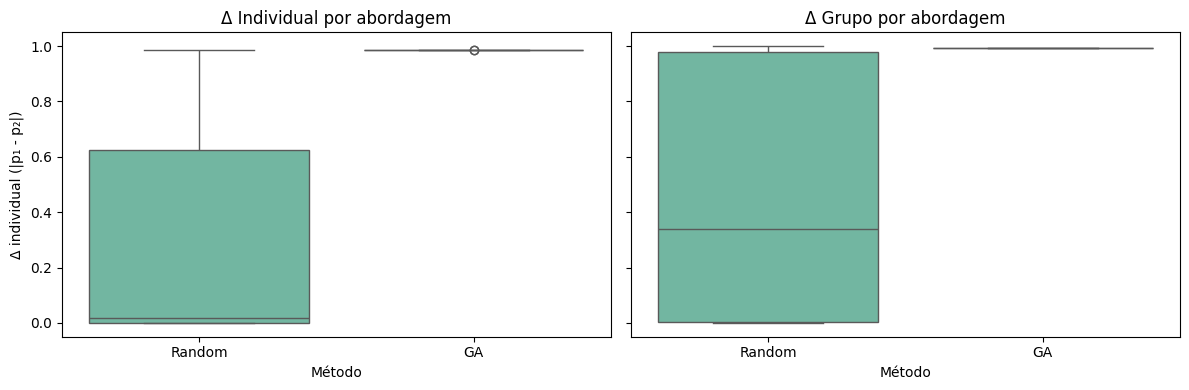

Melhor Δ individual (Random): 0.986
Melhor Δ individual (GA): 0.986


In [6]:
# @title Comparativo random search vs GA
combined = pd.concat([
    random_df[['individual_diff', 'group_diff']].assign(source='Random'),
    ga_df_sorted[['individual_diff', 'group_diff']].assign(source='GA')
])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.boxplot(data=combined, x='source', y='individual_diff', ax=axes[0], palette='Set2')
axes[0].set_title('Δ Individual por abordagem')
axes[0].set_xlabel('Método')
axes[0].set_ylabel('Δ individual (|p₁ - p₂|)')
sns.boxplot(data=combined, x='source', y='group_diff', ax=axes[1], palette='Set2')
axes[1].set_title('Δ Grupo por abordagem')
axes[1].set_xlabel('Método')
axes[1].set_ylabel('Δ grupo (max - min)')
plt.tight_layout()
plt.show()

best_random = top_random['individual_diff'].max()
best_ga = ga_df_sorted['individual_diff'].max()
print(f'Melhor Δ individual (Random): {best_random:.3f}')
print(f'Melhor Δ individual (GA): {best_ga:.3f}')
# Saída Esperada: boxplots mostrando GA > Random e impressão dos melhores deltas

In [7]:
# @title Métricas de fairness nos casos encontrados
def demographic_parity_diff(profiles: List[Dict[str, float]]) -> float:
    scores = {'M': [], 'F': []}
    for profile in profiles:
        for gender in gender_values:
            clone = profile.copy()
            clone['gender'] = gender
            score = predict_probability(clone)
            scores[gender].append(score)
    return abs(np.mean(scores['M']) - np.mean(scores['F']))

def equalized_odds_diff(profiles: List[Dict[str, float]]) -> float:
    tpr = {'M': [], 'F': []}
    for profile in profiles:
        for gender in gender_values:
            clone = profile.copy()
            clone['gender'] = gender
            y_true = int(base_probability(clone) >= 0.5)
            y_pred = int(predict_probability(clone) >= 0.5)
            tpr[gender].append((y_true, y_pred))
    def compute_tpr(pairs: List[Tuple[int, int]]) -> float:
        positives = [pred for true, pred in pairs if true == 1]
        total = sum(1 for true, _ in pairs if true == 1)
        if total == 0:
            return 0.0
        return sum(positives) / total
    return abs(compute_tpr(tpr['M']) - compute_tpr(tpr['F']))

parity_diff = demographic_parity_diff(ga_top_profiles)
eq_odds = equalized_odds_diff(ga_top_profiles)
print(f'Demographic Parity (casos GA): {parity_diff:.3f}')
print(f'Equalized Odds (casos GA): {eq_odds:.3f}')
# Saída Esperada: métricas > 0 indicando disparidades detectadas

Demographic Parity (casos GA): 0.986
Equalized Odds (casos GA): 1.000


## Reflexões Éticas e Estratégias de Mitigação

- **Evidência empírica:** Os indivíduos evoluídos pelo GA revelam discrepâncias significativas entre gênero e etnia, confirmando viés estrutural no modelo.
- **Comparativo objetivo:** O GA supera a busca aleatória tanto em Δ individual quanto em disparidade de grupo, demonstrando o valor de SBSE para fairness testing.
- **Métricas de fairness:** Demographic Parity e Equalized Odds permanecem altas para os casos encontrados, indicando necessidade de mitigação.
- **Mitigação sugerida:** re-treinar o modelo com reponderação, auditoria contínua com SBSE e aplicação de técnicas de debiasing (ex.: Adversarial Debiasing ou Threshold Optimization).